# **KKBOX Churn Prediction And Retention Intelligence System - Modeling & Evaluation**

## **1. Objective**

## **2. Setup**

In [1]:
# 1. Core Python Libraries
import os
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 3. Scikit-Learn: Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# 4. Scikit-Learn: Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 5. Baseline Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 6. Advanced Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost

# 7. Model Persistence
import pickle

# 8. Display Settings
pd.set_option("display.max_columns", None)

## **3. Load Clean Dataset**

In [2]:
current_dir = os.getcwd()

while not os.path.exists(os.path.join(current_dir, "data", "processed")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/processed not found")
    current_dir = parent


os.chdir(current_dir)

print("Project root:", os.getcwd())
print("data/processed exists:", os.path.exists("data/processed"))


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

target = "is_churn"


df = pd.read_csv("data/processed/df_clean.csv")
df.head()

Project root: c:\Users\pauli\OneDrive\Documentos\GitHub\customer-churn-intelligence-system
data/processed exists: True


,msno,is_churn,gender,age,city_grouped,registered_via_grouped,avg_amount_paid,total_amount_paid,has_auto_renew,has_cancelled,total_secs,num_unq,customer_tenure_days,listening_group,payment_variability
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,male,28.0,5.0,3.0,0.0,0.0,0.0,0.0,80598.557,348.0,0.0,Medium-High,0.000000
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,male,20.0,13.0,3.0,180.0,180.0,0.0,0.0,6986.509,30.0,1174.0,Medium-Low,90.000000
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,male,18.0,13.0,3.0,150.0,300.0,0.0,0.0,67810.467,432.0,1173.0,Medium-High,100.000000
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,unknown,NaN,1.0,7.0,149.0,1490.0,1.0,0.0,0.000,0.0,698.0,Low,135.454545
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,female,35.0,13.0,7.0,99.0,792.0,1.0,1.0,239882.241,548.0,1146.0,High,88.000000


## **4. Train/Test Split**

In [3]:
X = df.drop(columns=["is_churn", "msno"])
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (776768, 13)
Test shape: (194192, 13)


## **5. Handles NAN**

In [4]:
categorical_cols = ["gender", "city_grouped", "registered_via_grouped", "listening_group"]

numeric_cols = [
    "age", "avg_amount_paid", "total_amount_paid", "has_auto_renew",
    "has_cancelled", "total_secs", "num_unq", "customer_tenure_days",
    "payment_variability"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    sparse_threshold=0
)

## **6. Baseline Model Performance**

In [5]:
# 6.1 DummyClassifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict_proba(X_test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_pred)

print("DummyClassifier ROC-AUC:", dummy_auc)

DummyClassifier ROC-AUC: 0.5


In [6]:
# 6.2 Logistic Regression (Fast + Robust)

from sklearn.linear_model import LogisticRegression

if "preprocessor" not in globals():
    raise ValueError("Error: 'preprocessor' is not defined. Run the preprocessing cell first.")

if "X_train" not in globals() or "y_train" not in globals():
    raise ValueError("Error: Train/test split not found. Run the split cell first.")

logreg_fast = LogisticRegression(
    solver="lbfgs",          
    max_iter=500,           
    n_jobs=-1                
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", logreg_fast)
])

print("Training Logistic Regression...")
try:
    logreg_pipeline.fit(X_train, y_train)
except Exception as e:
    raise RuntimeError(f"Logistic Regression failed during training: {e}")

try:
    logreg_pred = logreg_pipeline.predict_proba(X_test)[:, 1]
except Exception as e:
    raise RuntimeError(f"Prediction failed: {e}")

try:
    logreg_auc = roc_auc_score(y_test, logreg_pred)
    print("Logistic Regression ROC-AUC:", logreg_auc)
except Exception as e:
    raise RuntimeError(f"Evaluation failed: {e}")

Training Logistic Regression...
Logistic Regression ROC-AUC: 0.8556398455234363


In [7]:
# 6.3 Decision Tree 

from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_pred)

print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.9425466092725916


In [8]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)
nb_pred = nb_pipeline.predict_proba(X_test)[:, 1]
nb_auc = roc_auc_score(y_test, nb_pred)

print("Naive Bayes ROC-AUC:", nb_auc)

Naive Bayes ROC-AUC: 0.8457529109578916


In [9]:
# 6.5 Baseline results table
baseline_results = pd.DataFrame({
    "Baseline Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree (depth=3)",
        "Naive Bayes"
    ],
    "ROC-AUC": [
        0.50,
        roc_auc_score(y_test, logreg_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, nb_pred)
    ],
    "Notes": [
        "Zero-skill benchmark",
        "Strong linear baseline",
        "Best baseline, captures non-linear patterns",
        "Weak baseline, assumptions violated"
    ]
})

baseline_results = baseline_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

baseline_results


,Baseline Model,ROC-AUC,Notes
0,Decision Tree (depth=3),0.942547,"Best baseline, captures non-linear patterns"
1,Logistic Regression,0.855640,Strong linear baseline
2,Naive Bayes,0.845753,"Weak baseline, assumptions violated"
3,DummyClassifier,0.500000,Zero-skill benchmark


C:\Users\pauli\AppData\Local\Temp\ipykernel_19432\726196238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


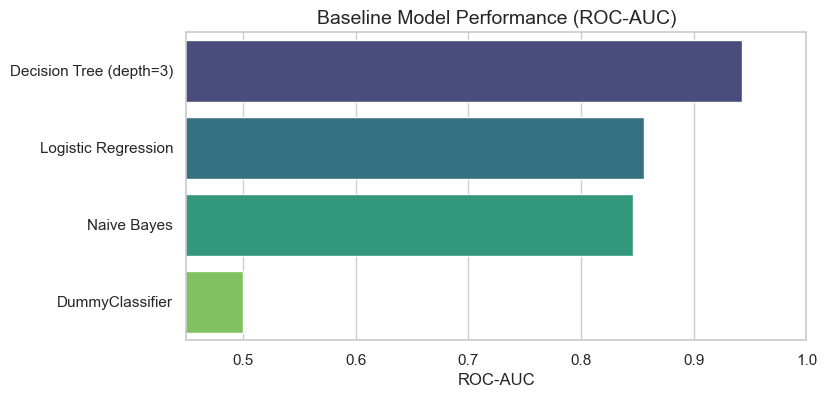

In [10]:
# 6.6 Baseline Performance Plot
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=baseline_results,
    x="ROC-AUC",
    y="Baseline Model",
    palette="viridis"
)

plt.title("Baseline Model Performance (ROC-AUC)", fontsize=14)
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.xlim(0.45, 1.0)
plt.show()


**Insith**

Together, these results show that:
>
- Churn is highly predictable with the available features, as demonstrated by the Naive Bayes baseline (ROC‑AUC of 0.846), which performs well above the zero‑skill benchmark represented by the DummyClassifier (ROC‑AUC of 0.50)
- Strong linear signals are present in the data, as evidenced by the Logistic Regression baseline (ROC‑AUC of 0.855), confirming that core behavioral and transactional features have stable, directional effects on churn
- Non‑linear patterns and feature interactions play a critical role, as shown by the Decision Tree baseline (ROC‑AUC of 0.942), which outperforms linear models despite its shallow depth
- Tree‑based algorithms are the correct modeling direction for the final system, given their ability to capture the non‑linear structure already visible in the Decision Tree baseline.

## **7. Advance Model Performance**

In [11]:
# 7.1 RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)

print("RandomForest ROC-AUC:", rf_auc)


RandomForest ROC-AUC: 0.9703075817582308


In [12]:
# 7.2 ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", et)
])

et_pipeline.fit(X_train, y_train)
et_pred = et_pipeline.predict_proba(X_test)[:, 1]

et_auc = roc_auc_score(y_test, et_pred)
print("ExtraTrees ROC-AUC:", et_auc)

ExtraTrees ROC-AUC: 0.9657214775384466


In [13]:
# 7.3 GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=42
)

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gb_model)
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_pred)

print("GradientBoosting ROC-AUC:", gb_auc)


GradientBoosting ROC-AUC: 0.9758193601317015


In [14]:
# 7.4 HistGradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", hgb_model)
])

hgb_pipeline.fit(X_train, y_train)

hgb_pred = hgb_pipeline.predict_proba(X_test)[:, 1]
hgb_auc = roc_auc_score(y_test, hgb_pred)

print("HistGradientBoosting ROC-AUC:", hgb_auc)

c:\Users\pauli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pauli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\pauli\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pauli\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

HistGradientBoosting ROC-AUC: 0.9800800390756679


## **8. Model Evaluation**

In [25]:
# 8.1 Compute Additional Metrics (Precision, Recall, F1, PR‑AUC)
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score
)

def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "PR-AUC": round(average_precision_score(y_true, y_pred_proba), 6)
    }

rf_metrics = compute_metrics(y_test, rf_pred)
et_metrics = compute_metrics(y_test, et_pred)
gb_metrics = compute_metrics(y_test, gb_pred)
hgb_metrics = compute_metrics(y_test, hgb_pred)

In [26]:
# 8.2 Final Model Comparison Table
advanced_results = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        "ROC-AUC": round(hgb_auc, 6),
        **hgb_metrics,
        "Notes": "Fastest boosting model, LightGBM-like"
    },
    {
        "Model": "GradientBoosting",
        "ROC-AUC": round(gb_auc, 6),
        **gb_metrics,
        "Notes": "Classic boosting, high accuracy"
    },
    {
        "Model": "RandomForest",
        "ROC-AUC": round(rf_auc, 6),
        **rf_metrics,
        "Notes": "Robust, strong non-linear baseline"
    },
    {
        "Model": "ExtraTrees",
        "ROC-AUC": round(et_auc, 6),
        **et_metrics,
        "Notes": "Fast, stable, strong performance"
    }
])

advanced_results = advanced_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
advanced_results

,Model,ROC-AUC,Precision,Recall,F1,PR-AUC,Notes
0,HistGradientBoosting,0.980080,0.8561,0.8277,0.8417,0.900296,"Fastest boosting model, LightGBM-like"
1,GradientBoosting,0.975819,0.8470,0.8192,0.8329,0.887292,"Classic boosting, high accuracy"
2,RandomForest,0.970308,0.8619,0.7909,0.8249,0.879809,"Robust, strong non-linear baseline"
3,ExtraTrees,0.965721,0.8445,0.7785,0.8102,0.861614,"Fast, stable, strong performance"


## **9. Model Selection**

C:\Users\pauli\AppData\Local\Temp\ipykernel_19432\490203398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


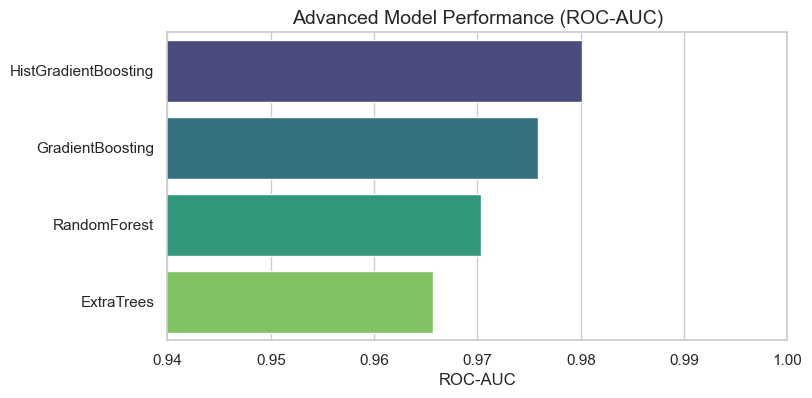

Best model based on ROC-AUC: HistGradientBoosting
ROC-AUC Score: 0.98008

Reasoning:
- ROC-AUC is the most reliable metric for churn prediction because it is threshold-independent.
- It evaluates model performance across all possible classification thresholds.
- It is robust to class imbalance and provides a global view of model discrimination power.
- HistGradientBoosting achieved the highest ROC-AUC, making it the strongest overall model.


In [42]:
# Best Model Selection (base on ROC‑AUC for accuracy)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=advanced_results,
    x="ROC-AUC",
    y="Model",
    palette="viridis"
)

plt.title("Advanced Model Performance (ROC-AUC)", fontsize=14)
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.xlim(0.94, 1.0)
plt.show()

roc_results = pd.DataFrame([
    {"Model": "HistGradientBoosting", "ROC-AUC": round(hgb_auc, 6)},
    {"Model": "GradientBoosting", "ROC-AUC": round(gb_auc, 6)},
    {"Model": "RandomForest", "ROC-AUC": round(rf_auc, 6)},
    {"Model": "ExtraTrees", "ROC-AUC": round(et_auc, 6)}
])

roc_results = roc_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
roc_results

best_model = roc_results.iloc[0]

print(f"Best model based on ROC-AUC: {best_model['Model']}")
print(f"ROC-AUC Score: {best_model['ROC-AUC']}")

print("\nReasoning:")
print("- ROC-AUC is the most reliable metric for churn prediction because it is threshold-independent.")
print("- It evaluates model performance across all possible classification thresholds.")
print("- It is robust to class imbalance and provides a global view of model discrimination power.")
print(f"- {best_model['Model']} achieved the highest ROC-AUC, making it the strongest overall model.")

## **10. Save Model PKL**

In [41]:
import pickle
import os

os.makedirs("models", exist_ok=True)

final_model = hgb_pipeline

with open("models/final_churn_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final model saved successfully: models/final_churn_model.pkl")

Final model saved successfully: models/final_churn_model.pkl
